# Evaluación en test del detector de daños (damage v2)

Evalúa un checkpoint del detector de daños de M3 (Mask R-CNN sobre CarDD, 6 clases: dent,
scratch, crack, glass shatter, lamp broken, tire flat) y lo compara contra una versión de
referencia (por defecto `damage/v1`) **en las mismas imágenes de test**.

1. COCO AP de **cajas** y **máscaras**, global, por tamaño y por clase.
2. Tiempo de inferencia (imágenes de CarDD y tamaño de la metodología de captura).
3. Curva de entrenamiento contra la referencia.
4. Comparación contra la referencia con bootstrap pareado por imagen (IC 95 %).
5. Predicciones contra ground truth: máscaras y cajas.
6. Salida cruda del detector para M3 (JSON + máscara PNG por daño). La asignación a partes,
   `pos_relativa` y el JSON final de M3 todavía no existen.

Regla: el mejor checkpoint de cada versión se eligió con `val`; el veredicto se calcula en `test`.

In [1]:
import contextlib
import copy
import io
import json
import os
import sys
import time
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from pycocotools import mask as mask_utils
from pycocotools.cocoeval import COCOeval
from torch.utils.data import DataLoader
from torchvision.transforms import functional as TF

# Project root = first parent folder that contains src/. The configs use paths relative to it.
current = Path(os.getcwd()).resolve()
while current != current.parent and not (current / "src").exists():
    current = current.parent
PROJECT_ROOT = current
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.detection.car_parts.compare_versions import interval, paired_bootstrap, per_image_eval
from src.detection.common.coco_dataset import build_dataset, collate_fn, polygons_to_mask
from src.detection.common.coco_eval import STAT_NAMES, collect_detections, load_coco_gt
from src.detection.common.model import build_model
from src.detection.damage.config import CONFIG

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos


## 1. Parámetros

Variables de entorno para correrlo sin editar: `M3_CHECKPOINT`, `M3_REFERENCE` (vacío = sin
comparación), `M3_SPLIT`, `M3_DEVICE`.

In [2]:
CHECKPOINT_PATH = Path(os.environ.get("M3_CHECKPOINT", "models/checkpoints/damage/v2/best_model.pth"))
REFERENCE_PATH = os.environ.get("M3_REFERENCE", "models/checkpoints/damage/v1/best_model.pth")
REFERENCE_PATH = Path(REFERENCE_PATH) if REFERENCE_PATH else None
SPLIT = os.environ.get("M3_SPLIT", "test")
DEVICE = torch.device(os.environ.get("M3_DEVICE", "cuda" if torch.cuda.is_available() else "cpu"))

SCORE_THRESHOLD = 0.5    # only for figures and the M3 output; AP uses every score
UNRELIABLE_BELOW = 10    # classes with fewer instances in the split are marked "poco fiable"
N_BOOTSTRAP = 1000
BOOTSTRAP_SEED = 0
# Masks are binarized at 0.5 inside collect_detections (coco_eval._encode_mask).
OUTPUT_DIR = Path("tests/detection/outputsM3") / CHECKPOINT_PATH.parent.name

print(f"Checkpoint: {CHECKPOINT_PATH}  |  referencia: {REFERENCE_PATH or 'ninguna'}")
print(f"Split: {SPLIT}  |  Device: {DEVICE}  |  Salida M3: {OUTPUT_DIR}")
if SPLIT != "test":
    print("AVISO: 'val' sirve para elegir el checkpoint; el resultado a reportar se calcula en 'test'.")

Checkpoint: models\checkpoints\damage\v2\best_model.pth  |  referencia: models\checkpoints\damage\v1\best_model.pth
Split: test  |  Device: cuda  |  Salida M3: tests\detection\outputsM3\v2


## 2. Cargar los checkpoints

In [3]:
def load_version(path):
    if not Path(path).exists():
        raise FileNotFoundError(f"No existe {path}")
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    model = build_model(ckpt["num_classes"], arch=ckpt.get("arch", "faster_rcnn"), pretrained=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE).eval()
    return {"model": model, "ckpt": ckpt, "categories": {int(k): v for k, v in ckpt["categories"].items()},
            "with_masks": bool(ckpt.get("with_masks", False)), "name": Path(path).parent.name}


def describe(v):
    c = v["ckpt"]
    print(f"[{v['name']}] {c.get('arch', 'faster_rcnn')}  |  época {c.get('epoch')}  |  elegido por "
          f"{c.get('select_by', 'bbox')} AP  |  augmentation: {c.get('augmented', 'no registrado')}  |  "
          f"semilla: {c.get('seed', '-')}")
    for t in ("bbox", "segm"):
        if t in c.get("coco", {}):
            print(f"    val {t}: AP {c['coco'][t]['AP']:.4f}  AP50 {c['coco'][t]['AP50']:.4f}")


current_v = load_version(CHECKPOINT_PATH)
reference_v = load_version(REFERENCE_PATH) if REFERENCE_PATH else None
categories = current_v["categories"]
WITH_MASKS = current_v["with_masks"]
describe(current_v)
if reference_v:
    describe(reference_v)
    assert reference_v["categories"] == categories, "la referencia tiene otras clases"

[v2] mask_rcnn  |  época 10  |  elegido por segm AP  |  augmentation: True  |  semilla: 42
    val bbox: AP 0.5297  AP50 0.7133
    val segm: AP 0.5124  AP50 0.6987
[v1] mask_rcnn  |  época 11  |  elegido por bbox AP  |  augmentation: no registrado  |  semilla: -
    val bbox: AP 0.5191  AP50 0.6873
    val segm: AP 0.5020  AP50 0.6735


## 3. Cargar el split

In [4]:
dataset = build_dataset(CONFIG, SPLIT)
assert dataset.categories == categories, "Las clases del dataset no coinciden con las del checkpoint"
img_ids = dataset.coco_image_ids
cat_ids = sorted(categories)
instances = Counter(a["category_id"] for a in dataset.coco_gt["annotations"]
                    if a["image_id"] in set(img_ids) and not a.get("iscrowd", 0))
print(f"Imágenes: {len(dataset)}  |  Instancias: {sum(instances.values())}")
for cid in cat_ids:
    print(f"  {categories[cid]:14} {instances[cid]:4d}")

Imágenes: 374  |  Instancias: 785
  dent            236
  scratch         307
  crack            70
  glass shatter    71
  lamp broken      69
  tire flat        32


## 4. Inferencia (una sola pasada por modelo)

In [5]:
loader = DataLoader(dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
detections = collect_detections(current_v["model"], loader, DEVICE, with_masks=WITH_MASKS)
print(f"[{current_v['name']}] detecciones: {len(detections)}  |  >= {SCORE_THRESHOLD}: "
      f"{sum(d['score'] >= SCORE_THRESHOLD for d in detections)}")
ref_detections = None
if reference_v:
    ref_detections = collect_detections(reference_v["model"], loader, DEVICE, with_masks=reference_v["with_masks"])
    print(f"[{reference_v['name']}] detecciones: {len(ref_detections)}")

Evaluating:   0%|          | 0/187 [00:00<?, ?batch/s]

Evaluating:   1%|          | 1/187 [00:01<04:33,  1.47s/batch]

Evaluating:   1%|          | 2/187 [00:02<03:00,  1.02batch/s]

Evaluating:   2%|▏         | 3/187 [00:02<02:20,  1.31batch/s]

Evaluating:   2%|▏         | 4/187 [00:03<02:01,  1.51batch/s]

...

Evaluating:  99%|█████████▉| 185/187 [01:30<00:00,  2.11batch/s]

Evaluating:  99%|█████████▉| 186/187 [01:30<00:00,  2.14batch/s]

Evaluating: 100%|██████████| 187/187 [01:30<00:00,  2.15batch/s]

Evaluating: 100%|██████████| 187/187 [01:30<00:00,  2.06batch/s]

[v1] detecciones: 1882


## 4b. Tiempo de inferencia

Una imagen a la vez, como en el sistema, tras `N_WARMUP` corridas de calentamiento y
sincronizando la GPU. Fases: **preparación** (imagen → tensor en GPU), **modelo** (incluye su
redimensionado interno al lado corto de 800 px), **salida** (filtrado por `SCORE_THRESHOLD` y
máscaras binarias copiadas a la CPU a resolución completa) y **total**. Se mide en las imágenes
de test (~1000 px, CarDD) y en el tamaño de la metodología de captura (4000×3000), generado
escalando imágenes de test: para el tiempo importa el tamaño, no el contenido.

In [6]:
N_WARMUP = 3
PROTOCOL_SIZE = (4000, 3000)
N_TIMED = min(40, len(dataset))
N_PROTOCOL = min(8, len(dataset))
model = current_v["model"]


def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def time_one(image_rgb):
    t0 = time.perf_counter()
    x = TF.to_tensor(image_rgb).to(DEVICE)
    sync()
    t1 = time.perf_counter()
    out = model([x])[0]
    sync()
    t2 = time.perf_counter()
    keep = out["scores"] >= SCORE_THRESHOLD
    if "masks" in out:
        (out["masks"][keep, 0] >= 0.5).cpu().numpy()
    out["boxes"][keep].cpu().numpy()
    t3 = time.perf_counter()
    return {"preparación": 1000 * (t1 - t0), "modelo": 1000 * (t2 - t1),
            "salida": 1000 * (t3 - t2), "total": 1000 * (t3 - t0)}


def read_rgb(path):
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)


def summarize(ms):
    ms = np.asarray(ms)
    return {"mediana": np.median(ms), "media": ms.mean(), "p90": np.percentile(ms, 90),
            "min": ms.min(), "max": ms.max()}


def collect(runs):
    return {phase: summarize([r[phase] for r in runs]) for phase in runs[0]}


paths = [os.path.join(dataset.images_dir, s[1]) for s in dataset.samples]
if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats(DEVICE)
warm = read_rgb(paths[0])
warm_big = cv2.resize(warm, PROTOCOL_SIZE, interpolation=cv2.INTER_CUBIC)
for _ in range(N_WARMUP):
    time_one(warm)
    time_one(warm_big)

timing = {}
read_ms, runs = [], []
for p in paths[:N_TIMED]:
    t = time.perf_counter()
    img = read_rgb(p)
    read_ms.append(1000 * (time.perf_counter() - t))
    runs.append(time_one(img))
timing[f"test CarDD (~1000 px, {N_TIMED} imgs)"] = {"lectura": summarize(read_ms), **collect(runs)}
big_runs = [time_one(cv2.resize(read_rgb(p), PROTOCOL_SIZE, interpolation=cv2.INTER_CUBIC))
            for p in paths[:N_PROTOCOL]]
timing[f"protocolo {PROTOCOL_SIZE[0]}x{PROTOCOL_SIZE[1]} ({N_PROTOCOL} imgs)"] = collect(big_runs)

device_name = torch.cuda.get_device_name(DEVICE) if DEVICE.type == "cuda" else "CPU"
print(f"Dispositivo: {device_name}  |  precisión: FP32  |  lote: 1")
print(f"{'':34} {'':12} {'mediana':>8} {'media':>8} {'p90':>8} {'min':>8} {'max':>8}   (ms)")
for size, parts in timing.items():
    for what, s in parts.items():
        print(f"{size:34} {what:12} {s['mediana']:8.1f} {s['media']:8.1f} {s['p90']:8.1f} {s['min']:8.1f} {s['max']:8.1f}")
if DEVICE.type == "cuda":
    print(f"Memoria GPU pico durante la medición: {torch.cuda.max_memory_allocated(DEVICE) / 1024**3:.2f} GB")

Dispositivo: NVIDIA GeForce RTX 3050 6GB Laptop GPU  |  precisión: FP32  |  lote: 1
                                                 mediana    media      p90      min      max   (ms)
test CarDD (~1000 px, 40 imgs)     lectura          11.3     11.2     12.6      7.8     14.2
test CarDD (~1000 px, 40 imgs)     preparación       3.6      3.7      4.5      2.7      6.4
test CarDD (~1000 px, 40 imgs)     modelo          200.8    202.9    214.7    183.3    239.5
test CarDD (~1000 px, 40 imgs)     salida            0.7      1.2      3.0      0.4      4.7
test CarDD (~1000 px, 40 imgs)     total           204.8    207.9    220.7    187.1    247.8
protocolo 4000x3000 (8 imgs)       preparación      41.8     48.8     69.1     38.0     76.6
protocolo 4000x3000 (8 imgs)       modelo          732.8   1043.9   2326.3    194.1   2738.0
protocolo 4000x3000 (8 imgs)       salida           36.8     58.0    102.0     18.2    202.2
protocolo 4000x3000 (8 imgs)       total           810.8   1150.8   2458

## 5. COCO AP en el split

AP@0.5:0.95 sobre las 6 clases y las imágenes del split. `AP_small/medium/large` usan las
áreas COCO (< 32², 32²–96², > 96² px en la imagen original).

In [7]:
coco_gt = load_coco_gt(dataset.coco_gt)


def coco_scores(dets, iou_type):
    with contextlib.redirect_stdout(io.StringIO()):
        ev = COCOeval(coco_gt, coco_gt.loadRes(copy.deepcopy(dets)), iou_type)
        ev.params.catIds, ev.params.imgIds = cat_ids, img_ids
        ev.evaluate()
        ev.accumulate()
        ev.summarize()
    per_class = {}
    for k, cid in enumerate(ev.params.catIds):
        p = ev.eval["precision"][:, :, k, 0, -1]
        per_class[cid] = float(p[p > -1].mean()) if (p > -1).any() else None
    return dict(zip(STAT_NAMES, map(float, ev.stats))), per_class


IOU_TYPES = ["bbox"] + (["segm"] if WITH_MASKS else [])
scores = {t: coco_scores(detections, t) for t in IOU_TYPES}

print(f"{'':8} {'AP':>7} {'AP50':>7} {'AP75':>7} {'APs':>7} {'APm':>7} {'APl':>7} {'AR100':>7}")
for t in IOU_TYPES:
    s = scores[t][0]
    print(f"{'caja' if t == 'bbox' else 'máscara':8} {s['AP']:7.4f} {s['AP50']:7.4f} {s['AP75']:7.4f} "
          f"{s['AP_small']:7.4f} {s['AP_medium']:7.4f} {s['AP_large']:7.4f} {s['AR_100']:7.4f}")

              AP    AP50    AP75     APs     APm     APl   AR100
caja      0.5275  0.7297  0.5736  0.3539  0.2911  0.5404  0.6629
máscara   0.5075  0.7066  0.5140  0.1714  0.2404  0.5111  0.6269


## 6. AP por clase

clase           inst    caja  máscara  nota
glass shatter     71   0.840    0.851  
tire flat         32   0.798    0.859  
lamp broken       69   0.605    0.605  
dent             236   0.352    0.351  
scratch          307   0.326    0.256  
crack             70   0.244    0.123  


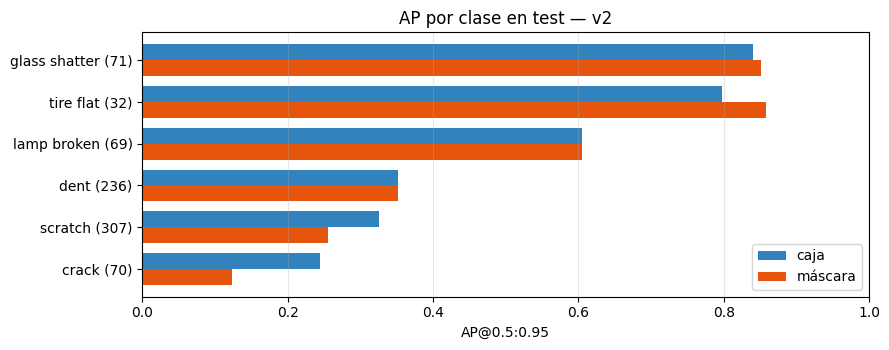

In [8]:
rows = []
for cid in cat_ids:
    row = {"clase": categories[cid], "instancias": instances[cid]}
    for t in IOU_TYPES:
        row[t] = scores[t][1][cid]
    rows.append(row)
rows.sort(key=lambda r: -(r["bbox"] or 0))

fmt = lambda v: "   -  " if v is None else f"{v:6.3f}"
print(f"{'clase':14} {'inst':>5} {'caja':>7}" + (f" {'máscara':>8}" if WITH_MASKS else "") + "  nota")
for r in rows:
    note = "poco fiable" if r["instancias"] < UNRELIABLE_BELOW else ""
    line = f"{r['clase']:14} {r['instancias']:5d} {fmt(r['bbox']):>7}"
    if WITH_MASKS:
        line += f" {fmt(r['segm']):>8}"
    print(line + f"  {note}")

fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(len(rows))[::-1]
h = 0.38
ax.barh(y + h / 2, [r["bbox"] for r in rows], h, label="caja", color="#3182bd")
if WITH_MASKS:
    ax.barh(y - h / 2, [r["segm"] for r in rows], h, label="máscara", color="#e6550d")
ax.set_yticks(y)
ax.set_yticklabels([f"{r['clase']} ({r['instancias']})" for r in rows])
ax.set_xlim(0, 1)
ax.set_xlabel("AP@0.5:0.95")
ax.set_title(f"AP por clase en {SPLIT} — {current_v['name']}")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Curva de entrenamiento

`metrics.json` de cada versión: AP de validación por época (caja y máscara) y loss de
entrenamiento. La línea vertical marca la bajada de LR (StepLR) si se registró. La estrella es
la época guardada en `best_model.pth`.

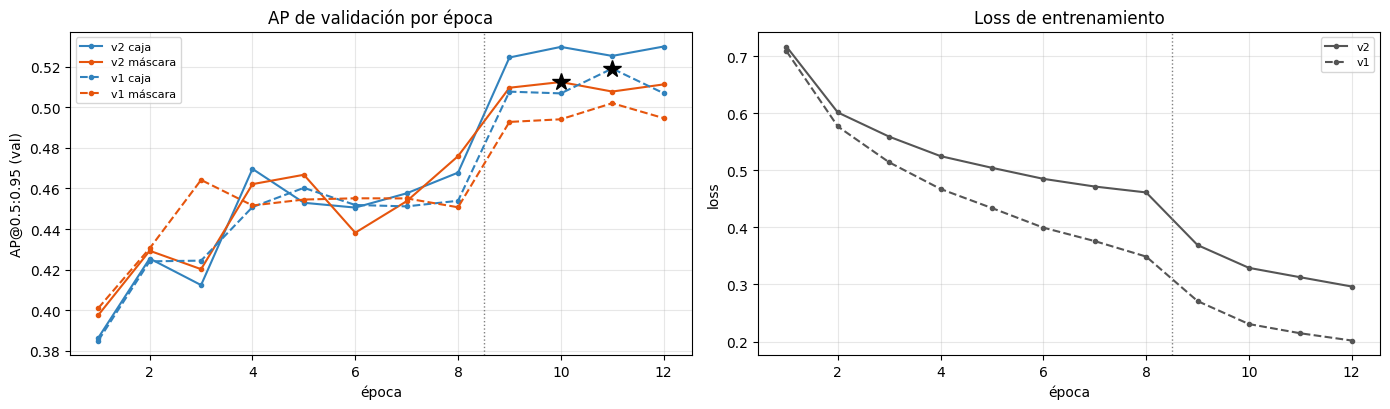

[v2] máx. val mask AP 0.5124 (época 10)  |  última época: caja 0.5299, máscara 0.5113, loss 0.296
[v1] máx. val mask AP 0.5020 (época 11)  |  última época: caja 0.5069, máscara 0.4947, loss 0.202


In [9]:
def load_history(version):
    path = Path(CHECKPOINT_PATH if version is current_v else REFERENCE_PATH).parent / "metrics.json"
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else None


histories = [(v, load_history(v)) for v in (current_v, reference_v) if v]
fig, (ax_ap, ax_loss) = plt.subplots(1, 2, figsize=(14, 4.2))
for (v, hist), style in zip(histories, ("-", "--")):
    if not hist:
        continue
    ep = [r["epoch"] for r in hist]
    ax_ap.plot(ep, [r["coco"]["bbox"]["AP"] for r in hist], style, color="#3182bd", marker="o", ms=3,
               label=f"{v['name']} caja")
    ax_ap.plot(ep, [r["coco"]["segm"]["AP"] for r in hist], style, color="#e6550d", marker="o", ms=3,
               label=f"{v['name']} máscara")
    ax_loss.plot(ep, [r["train_loss"] for r in hist], style, color="#555555", marker="o", ms=3, label=v["name"])
    best = v["ckpt"].get("epoch")
    key = "segm" if v["ckpt"].get("select_by") == "segm" else "bbox"
    best_rec = next((r for r in hist if r["epoch"] == best), None)
    if best_rec:
        ax_ap.plot(best, best_rec["coco"][key]["AP"], "*", color="black", ms=13)
    lrs = [r.get("lr") for r in hist]
    for e, (a, b) in zip(ep[1:], zip(lrs, lrs[1:])):
        if a and b and b < a:
            ax_ap.axvline(e - 0.5, color="gray", ls=":", lw=1)
            ax_loss.axvline(e - 0.5, color="gray", ls=":", lw=1)
ax_ap.set(xlabel="época", ylabel="AP@0.5:0.95 (val)", title="AP de validación por época")
ax_loss.set(xlabel="época", ylabel="loss", title="Loss de entrenamiento")
for ax in (ax_ap, ax_loss):
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for v, hist in histories:
    if hist:
        best = max(hist, key=lambda r: r["coco"]["segm"]["AP"])
        last = hist[-1]
        print(f"[{v['name']}] máx. val mask AP {best['coco']['segm']['AP']:.4f} (época {best['epoch']})  |  "
              f"última época: caja {last['coco']['bbox']['AP']:.4f}, máscara {last['coco']['segm']['AP']:.4f}, "
              f"loss {last['train_loss']:.3f}")

## 8. Comparación contra la referencia (mismas imágenes, bootstrap pareado)

Diferencia **actual − referencia** en AP y AP50, con IC 95 % por bootstrap pareado por imagen
(`N_BOOTSTRAP` remuestreos, mismas imágenes remuestreadas para ambos modelos). Usa las funciones
de `src/detection/car_parts/compare_versions.py`, verificadas contra pycocotools. Si el IC no
cruza 0, la diferencia es distinguible del ruido de muestreo de este split.

In [10]:
if reference_v is None:
    print("Sin referencia: define M3_REFERENCE para comparar.")
else:
    types = [t for t in ("bbox", "segm") if t == "bbox" or (WITH_MASKS and reference_v["with_masks"])]
    evals = {}
    for t in types:
        evals[f"ref_{t}"] = per_image_eval(dataset.coco_gt, ref_detections, t, cat_ids, img_ids)
        evals[f"cur_{t}"] = per_image_eval(dataset.coco_gt, detections, t, cat_ids, img_ids)
    boot = paired_bootstrap(evals, N_BOOTSTRAP, BOOTSTRAP_SEED)
    ref_scores = {t: coco_scores(ref_detections, t) for t in types}

    print(f"{'':10} {'métrica':6} {reference_v['name']:>10} {current_v['name']:>10} {'diferencia':>11}   IC 95 % de la diferencia")
    comparison = {}
    for t in types:
        for m in ("AP", "AP50"):
            ref, cur = ref_scores[t][0][m], scores[t][0][m]
            ci = interval(boot[f"cur_{t}"][m] - boot[f"ref_{t}"][m])
            comparison[(t, m)] = (ref, cur, cur - ref, ci)
            label = "caja" if t == "bbox" else "máscara"
            verdict = "mejora" if ci["low"] > 0 else ("empeora" if ci["high"] < 0 else "no distinguible")
            print(f"{label:10} {m:6} {ref:10.4f} {cur:10.4f} {cur - ref:+11.4f}   "
                  f"[{ci['low']:+.4f}, {ci['high']:+.4f}]  {verdict}")

    print(f"\nAP por clase (AP@0.5:0.95): {reference_v['name']} → {current_v['name']}")
    print(f"{'clase':14} {'inst':>5} " + "  ".join(f"{('caja' if t == 'bbox' else 'máscara'):>22}" for t in types))
    for cid in sorted(cat_ids, key=lambda c: -(scores['bbox'][1][c] or 0)):
        cells = []
        for t in types:
            a, b = ref_scores[t][1][cid], scores[t][1][cid]
            cells.append(f"{a:6.3f} → {b:6.3f} ({b - a:+.3f})")
        print(f"{categories[cid]:14} {instances[cid]:5d} " + "  ".join(f"{c:>22}" for c in cells))

           métrica         v1         v2  diferencia   IC 95 % de la diferencia
caja       AP         0.5331     0.5275     -0.0056   [-0.0283, +0.0196]  no distinguible
caja       AP50       0.7138     0.7297     +0.0158   [-0.0148, +0.0480]  no distinguible
máscara    AP         0.4949     0.5075     +0.0125   [-0.0060, +0.0330]  no distinguible
máscara    AP50       0.6830     0.7066     +0.0235   [-0.0063, +0.0538]  no distinguible

AP por clase (AP@0.5:0.95): v1 → v2
clase           inst                   caja                 máscara
glass shatter     71  0.867 →  0.840 (-0.027)   0.867 →  0.851 (-0.016)
tire flat         32  0.837 →  0.798 (-0.038)   0.860 →  0.859 (-0.001)
lamp broken       69  0.570 →  0.605 (+0.035)   0.565 →  0.605 (+0.039)
dent             236  0.333 →  0.352 (+0.019)   0.325 →  0.351 (+0.026)
scratch          307  0.321 →  0.326 (+0.004)   0.263 →  0.256 (-0.007)
crack             70  0.271 →  0.244 (-0.026)   0.089 →  0.123 (+0.034)


## 9. Predicciones contra ground truth

Una imagen por clase de daño (la primera del split que la contiene), en dos vistas: **9a
máscaras** y **9b cajas**. Izquierda: predicciones con confianza ≥ `SCORE_THRESHOLD`; derecha:
ground truth. Cada clase tiene el mismo color en todas las figuras.

In [11]:
palette = {1: (231, 76, 60), 2: (52, 152, 219), 3: (241, 196, 15), 4: (46, 204, 113),
           5: (155, 89, 182), 6: (230, 126, 34)}
palette = {cid: palette.get(cid, (200, 200, 200)) for cid in cat_ids}
dets_by_image = {}
for d in detections:
    dets_by_image.setdefault(d["image_id"], []).append(d)


def put_label(img, text, org, color):
    x, y = int(org[0]), int(max(org[1], 14))
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 4, cv2.LINE_AA)
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)


def sample_items(image_id, anns, height, width):
    preds = []
    for d in dets_by_image.get(image_id, []):
        if d["score"] < SCORE_THRESHOLD:
            continue
        x, y, w, h = d["bbox"]
        mask = mask_utils.decode(d["segmentation"]) if "segmentation" in d else None
        preds.append((d["category_id"], mask, (x, y, x + w, y + h), f"{categories[d['category_id']]} {d['score']:.2f}"))
    gts = []
    for a in anns:
        x, y, w, h = a["bbox"]
        gts.append((a["category_id"], polygons_to_mask(a["segmentation"], height, width),
                    (x, y, x + w, y + h), categories[a["category_id"]]))
    return preds, gts


chosen, seen = [], set()
for sample in dataset.samples:
    classes = {a["category_id"] for a in sample[4]}
    new = sorted(classes - seen)
    if new:
        chosen.append((sample, categories[new[0]]))
        seen |= classes
    if seen >= set(cat_ids):
        break

samples = []
for (image_id, file_name, width, height, anns), shown_for in chosen:
    image = read_rgb(os.path.join(dataset.images_dir, file_name))
    samples.append((file_name, shown_for, image, *sample_items(image_id, anns, height, width)))
print(f"{len(samples)} imágenes: " + ", ".join(f"{s[0]} ({s[1]})" for s in samples))

5 imágenes: 000012.jpg (tire flat), 000015.jpg (scratch), 000023.jpg (dent), 000040.jpg (lamp broken), 000042.jpg (crack)


### 9a. Máscaras

Máscaras rellenas con el color de su clase, contorneadas, con la etiqueta en su centro. Los
daños grandes se dibujan primero para que los pequeños queden encima.

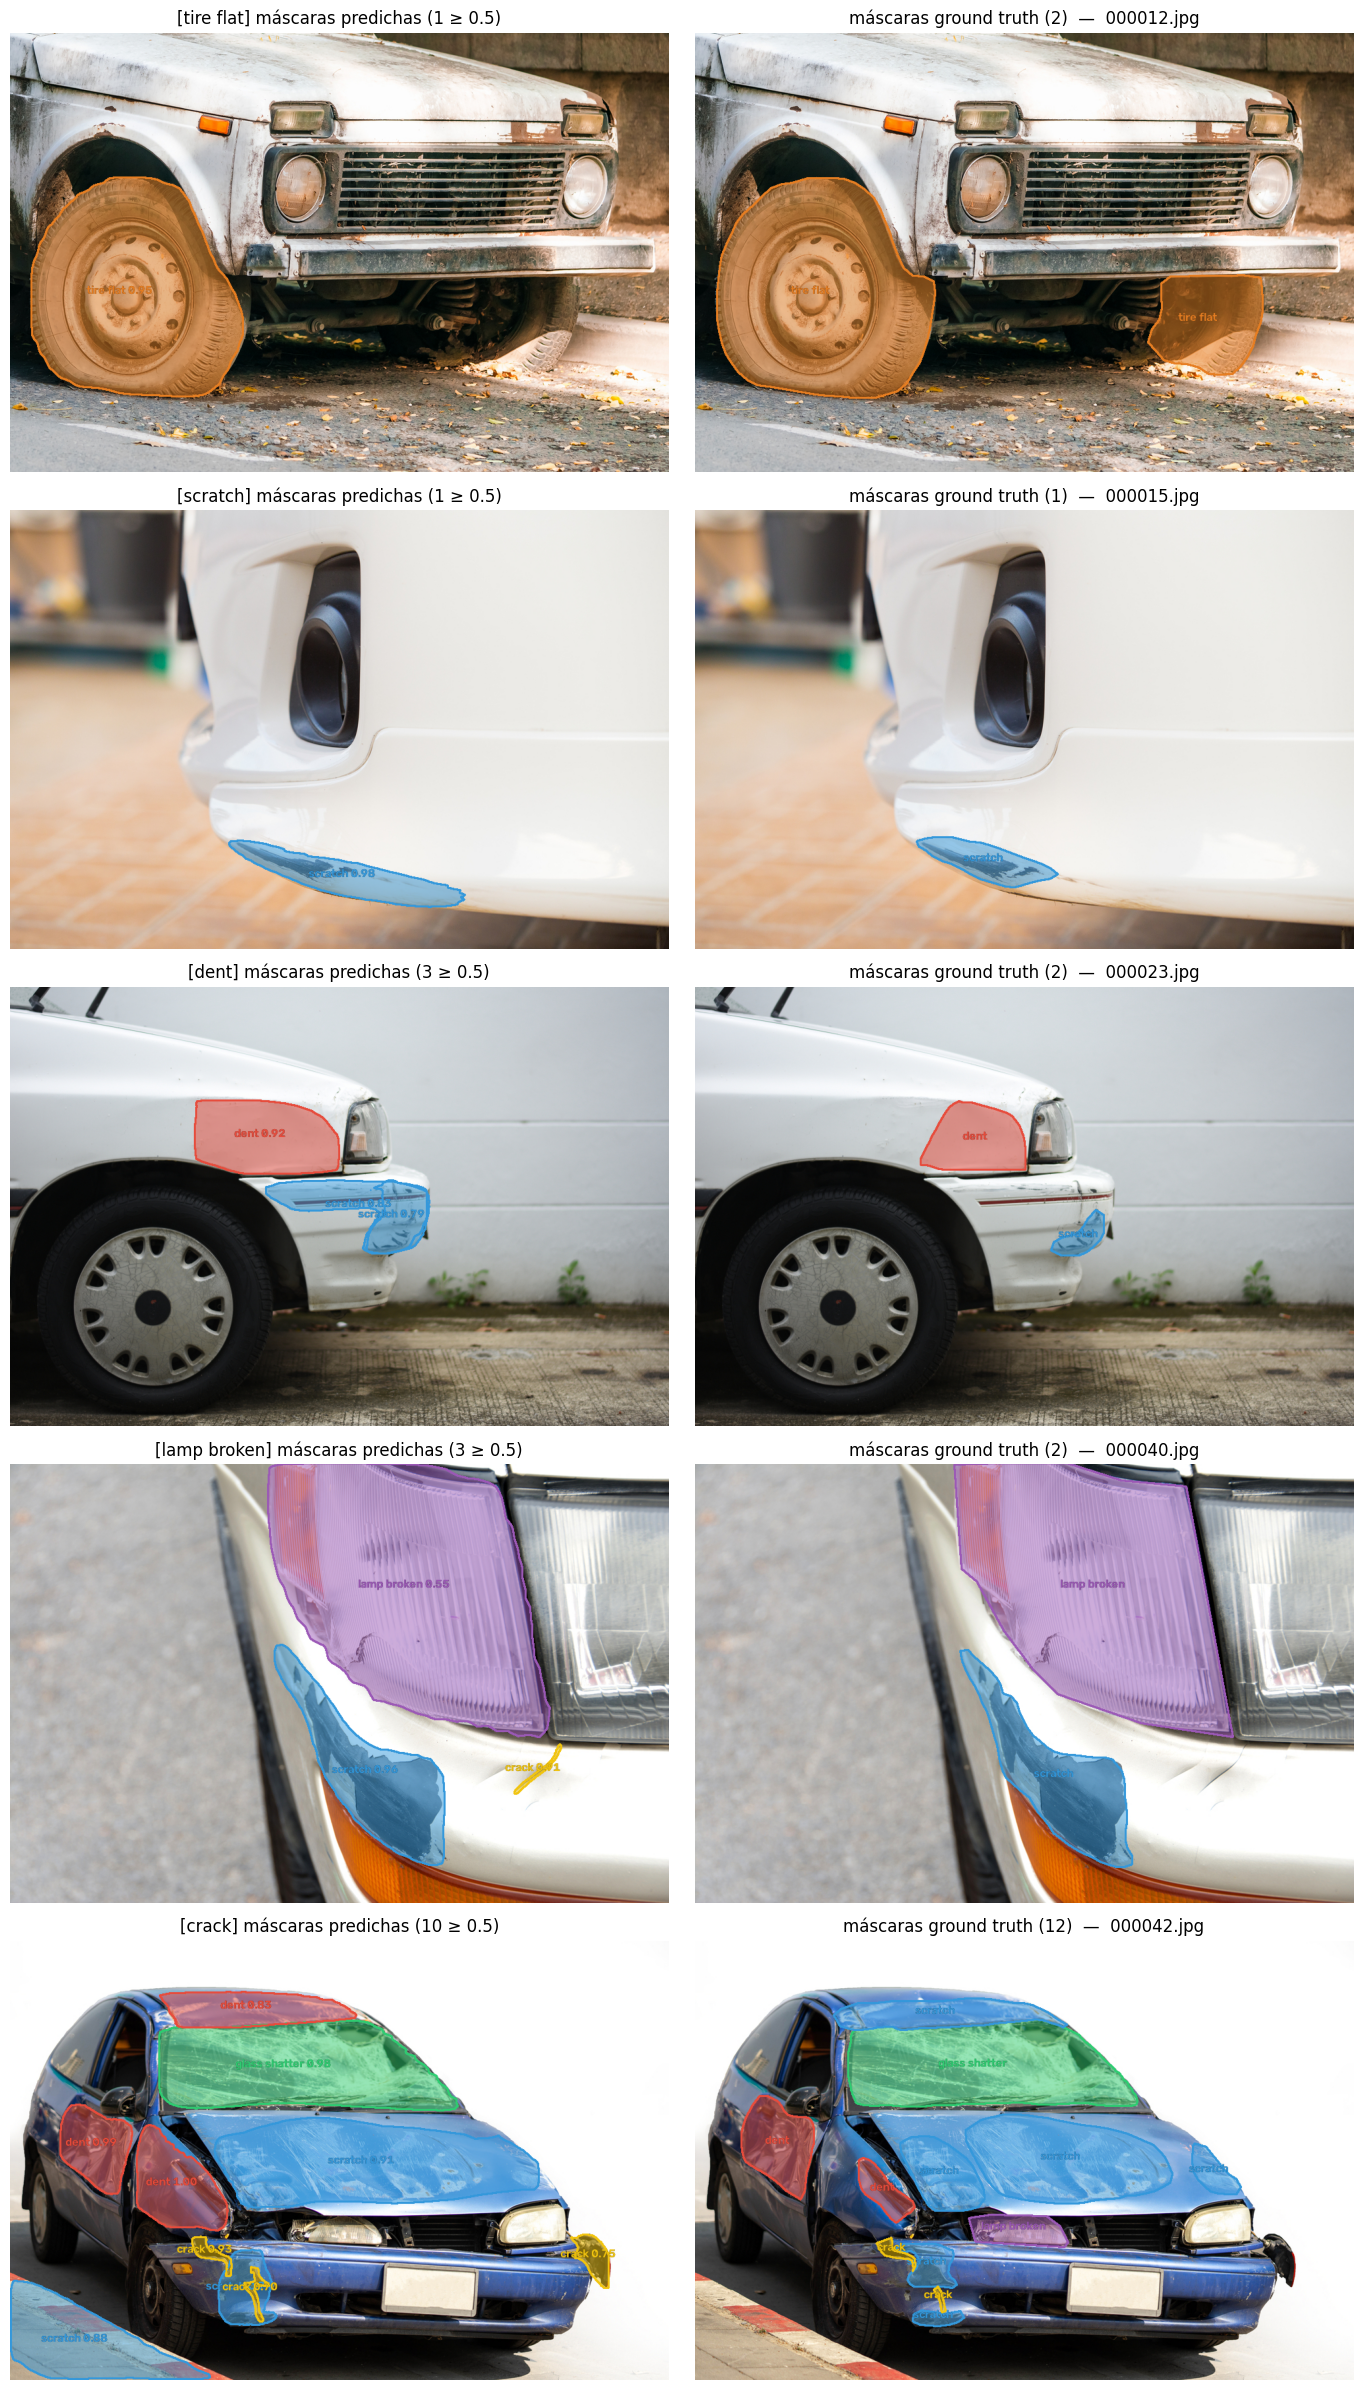

In [12]:
def draw_masks(image_rgb, items, alpha=0.5):
    items = sorted((it for it in items if it[1] is not None), key=lambda it: -int(it[1].sum()))
    overlay = image_rgb.copy()
    for cid, mask, _, _ in items:
        overlay[mask.astype(bool)] = palette[cid]
    out = cv2.addWeighted(overlay, alpha, image_rgb, 1 - alpha, 0)
    for cid, mask, _, text in items:
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, contours, -1, palette[cid], 2)
        m = cv2.moments(mask.astype(np.uint8), binaryImage=True)
        if m["m00"] > 0:
            put_label(out, text, (m["m10"] / m["m00"] - 5 * len(text), m["m01"] / m["m00"]), palette[cid])
    return out, len(items)


fig, axes = plt.subplots(len(samples), 2, figsize=(14, 4.8 * len(samples)))
axes = np.atleast_2d(axes)
for row, (file_name, shown_for, image, preds, gts) in enumerate(samples):
    pred_img, n_pred = draw_masks(image, preds)
    gt_img, n_gt = draw_masks(image, gts)
    axes[row, 0].imshow(pred_img)
    axes[row, 0].set_title(f"[{shown_for}] máscaras predichas ({n_pred} ≥ {SCORE_THRESHOLD})")
    axes[row, 1].imshow(gt_img)
    axes[row, 1].set_title(f"máscaras ground truth ({n_gt})  —  {file_name}")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()

### 9b. Cajas

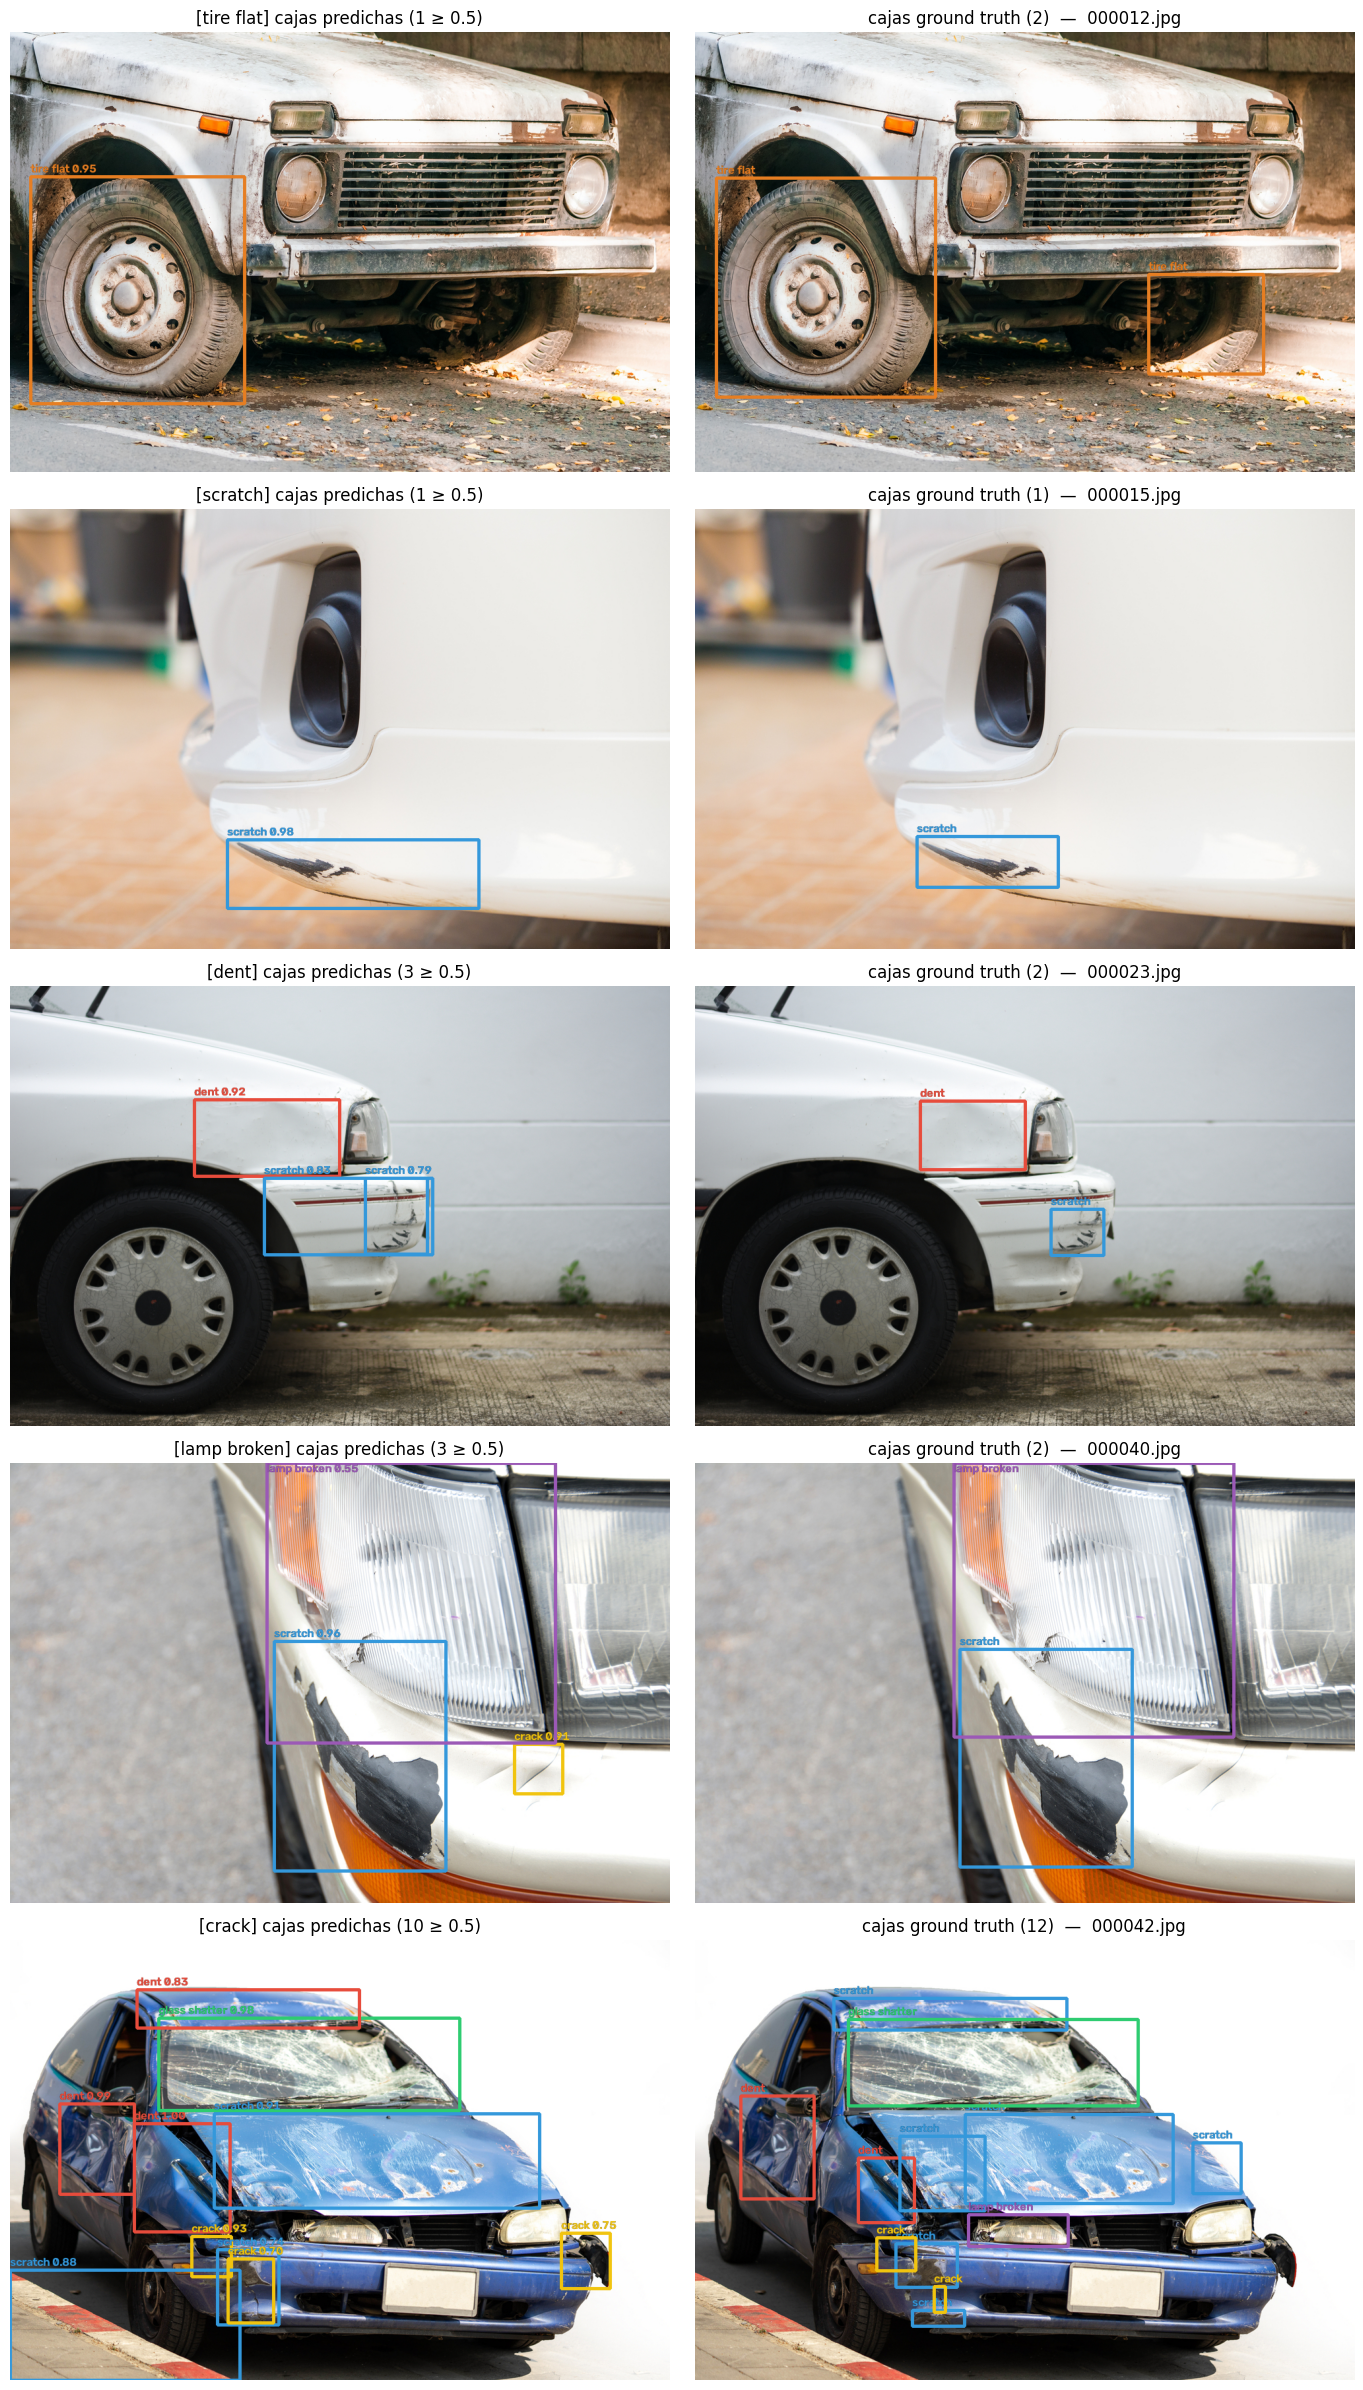

In [13]:
def draw_boxes(image_rgb, items):
    out = image_rgb.copy()
    for cid, _, box, text in items:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(out, (x1, y1), (x2, y2), palette[cid], 3)
        put_label(out, text, (x1, y1 - 6), palette[cid])
    return out


fig, axes = plt.subplots(len(samples), 2, figsize=(14, 4.8 * len(samples)))
axes = np.atleast_2d(axes)
for row, (file_name, shown_for, image, preds, gts) in enumerate(samples):
    axes[row, 0].imshow(draw_boxes(image, preds))
    axes[row, 0].set_title(f"[{shown_for}] cajas predichas ({len(preds)} ≥ {SCORE_THRESHOLD})")
    axes[row, 1].imshow(draw_boxes(image, gts))
    axes[row, 1].set_title(f"cajas ground truth ({len(gts)})  —  {file_name}")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()

## 10. Salida cruda del detector para M3

Un JSON por imagen con los daños de confianza ≥ `SCORE_THRESHOLD` y su máscara como PNG (0/255,
tamaño original). `bbox` en `[x1, y1, x2, y2]` píxeles. Faltan los campos `parte`,
`solapamiento` y `pos_relativa` del JSON de M3: requieren el módulo de asignación a partes, que
todavía no existe. `tipo` usa los nombres de CarDD.

In [14]:
mask_dir = OUTPUT_DIR / "masks"
mask_dir.mkdir(parents=True, exist_ok=True)
written = []
for image_id, file_name, width, height, _ in dataset.samples:
    stem = Path(file_name).stem
    found = sorted((d for d in dets_by_image.get(image_id, []) if d["score"] >= SCORE_THRESHOLD),
                   key=lambda d: -d["score"])
    danos = []
    for k, d in enumerate(found, start=1):
        x, y, w, h = d["bbox"]
        entry = {"id": f"d-{k:02d}", "tipo": categories[d["category_id"]], "confianza": round(d["score"], 4),
                 "bbox": [round(v, 1) for v in (x, y, x + w, y + h)], "area_px": None, "mascara": None}
        if "segmentation" in d:
            mask = mask_utils.decode(d["segmentation"])
            mask_path = mask_dir / f"{stem}_d{k:02d}.png"
            cv2.imwrite(str(mask_path), mask * 255)
            entry["area_px"] = int(mask.sum())
            entry["mascara"] = str(mask_path.relative_to(OUTPUT_DIR)).replace(os.sep, "/")
        danos.append(entry)
    payload = {"imagen": file_name, "image_id": int(image_id), "width": int(width), "height": int(height),
               "checkpoint": str(CHECKPOINT_PATH).replace(os.sep, "/"), "score_threshold": SCORE_THRESHOLD,
               "danos": danos}
    out_path = OUTPUT_DIR / f"{stem}.json"
    out_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
    written.append(out_path)

n_danos = sum(len(json.loads(p.read_text(encoding="utf-8"))["danos"]) for p in written)
print(f"{len(written)} JSON ({n_danos} daños) en {OUTPUT_DIR}  |  máscaras PNG en {mask_dir}")
example = next(p for p in written if json.loads(p.read_text(encoding="utf-8"))["danos"])
print(json.dumps(json.loads(example.read_text(encoding="utf-8"))["danos"][:2], indent=2, ensure_ascii=False))

374 JSON (1232 daños) en tests\detection\outputsM3\v2  |  máscaras PNG en tests\detection\outputsM3\v2\masks
[
  {
    "id": "d-01",
    "tipo": "tire flat",
    "confianza": 0.9492,
    "bbox": [
      31.8,
      219.5,
      355.5,
      563.1
    ],
    "area_px": 84233,
    "mascara": "masks/000012_d01.png"
  }
]


## 11. Resumen

In [15]:
print(f"Checkpoint: {CHECKPOINT_PATH}  (época {current_v['ckpt'].get('epoch')})")
print(f"Split: {SPLIT}  |  {len(dataset)} imágenes  |  {sum(instances.values())} instancias")
for t in IOU_TYPES:
    s = scores[t][0]
    print(f"  {'caja   ' if t == 'bbox' else 'máscara'}  AP {s['AP']:.4f}  AP50 {s['AP50']:.4f}  AP75 {s['AP75']:.4f}  "
          f"APs {s['AP_small']:.4f}  APm {s['AP_medium']:.4f}  APl {s['AP_large']:.4f}")
if reference_v is not None:
    for (t, m), (ref, cur, diff, ci) in comparison.items():
        print(f"  vs {reference_v['name']} {'caja' if t == 'bbox' else 'máscara'} {m}: {diff:+.4f} "
              f"[{ci['low']:+.4f}, {ci['high']:+.4f}]")
target = [r for r in rows if r["clase"] in ("dent", "scratch", "crack")]
print("Clases objetivo de la tesis (caja AP): " + ", ".join(f"{r['clase']} {r['bbox']:.3f}" for r in target))
for size, parts in timing.items():
    print(f"Inferencia {size}: {parts['total']['mediana']:.0f} ms por imagen (mediana, total)")

Checkpoint: models\checkpoints\damage\v2\best_model.pth  (época 10)
Split: test  |  374 imágenes  |  785 instancias
  caja     AP 0.5275  AP50 0.7297  AP75 0.5736  APs 0.3539  APm 0.2911  APl 0.5404
  máscara  AP 0.5075  AP50 0.7066  AP75 0.5140  APs 0.1714  APm 0.2404  APl 0.5111
  vs v1 caja AP: -0.0056 [-0.0283, +0.0196]
  vs v1 caja AP50: +0.0158 [-0.0148, +0.0480]
  vs v1 máscara AP: +0.0125 [-0.0060, +0.0330]
  vs v1 máscara AP50: +0.0235 [-0.0063, +0.0538]
Clases objetivo de la tesis (caja AP): dent 0.352, scratch 0.326, crack 0.244
Inferencia test CarDD (~1000 px, 40 imgs): 205 ms por imagen (mediana, total)
Inferencia protocolo 4000x3000 (8 imgs): 811 ms por imagen (mediana, total)
